# Pattern 1 — Tool Use (Build)

How to build it:

1. State
    - Use `Annotated[list, add_messages]` for your messages.
    - This state is designed to automatically handle `AIMessage` and `ToolMessage` objects.

2. Tool node
    - Create a node that executes tools.
    - It should parse the `tool_calls` from the last message, invoke the corresponding functions, and return a list of `ToolMessage` objects.

3. Conditional edge
    - Create a function that checks the `tool_calls` attribute of the last message (e.g., `if getattr(last_message, "tool_calls", None):`).
    - Use that check to decide whether to route execution to the tool node.

In [7]:
# !pip install langgraph
# !pip install langchain_google_genai

In [8]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0,
    api_key = GEMINI_API_KEY)


In [41]:
from google.colab import userdata
GEMINI_API_KEY = userdata.get('GEMINI_API_KEY')

from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    temperature=0,
    api_key = GEMINI_API_KEY)

from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from typing import TypedDict, Annotated
from langchain_core.messages import ToolMessage

# 1. State
class AgentState(TypedDict):
    messages: Annotated[list, add_messages]


def weather_tool(query: str):
    '''This function is used for returning the weather'''
    return "The weather is 70 degrees and sunny."


llm_with_tools = llm.bind_tools([weather_tool])

# 2. Tool Node
def tool_node(state: AgentState):
    last_message = state['messages'][-1]
    tool_call = last_message.tool_calls[0]

    #logic to run the actual tool function ...
    result = weather_tool(tool_call['args'])

    return {"messages": [ToolMessage(content=str(result), tool_call_id=tool_call['id'])]}

# Placeholder for the LLM-calling node
def model_function(state: AgentState):
    # In a real application, this would call your LLM
    # For now, let's just return a placeholder message
    output = llm_with_tools.invoke(state['messages'])
    return {"messages": [output]}


# 3. Conditional Logic
def should_use_tools(state: AgentState):
    last_message = state['messages'][-1]
    if last_message.tool_calls:
        return "tool_node"  # Go to the tool-calling node
    else:
        return END # Stop the graph

# --- Graph Setup ---
workflow = StateGraph(AgentState)
workflow.add_node("model_node", model_function) # Your LLM-calling node
workflow.add_node("tool_node", tool_node)

workflow.set_entry_point("model_node")

# The conditional edge routes to tools or to the end
workflow.add_conditional_edges(
    "model_node",
    should_use_tools,
    {
        "tool_node": "tool_node",
        END: END
    }
)

# The tool node *always* loops back to the model
workflow.add_edge("tool_node", "model_node")

app = workflow.compile()

app.invoke({"messages":("human", "What is the weather of Delhi")})


{'messages': [HumanMessage(content='What is the weather of Delhi', additional_kwargs={}, response_metadata={}, id='22a5f115-a240-4ead-a8c5-8ebdf88d517a'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'weather_tool', 'arguments': '{"query": "Delhi"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'grounding_metadata': {}, 'model_provider': 'google_genai'}, id='lc_run--f437dc3c-91d7-43d0-99d0-4297f173f6cd-0', tool_calls=[{'name': 'weather_tool', 'args': {'query': 'Delhi'}, 'id': '43d2665d-d81c-4c23-a636-72229d999d8d', 'type': 'tool_call'}], usage_metadata={'input_tokens': 47, 'output_tokens': 72, 'total_tokens': 119, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 57}}),
  ToolMessage(content='The weather is 70 degrees and sunny.', id='49557315-959d-4141-8ac2-90d7d1cd480a', tool_call_id='43d2665d-d81c-4c23-a636-72229

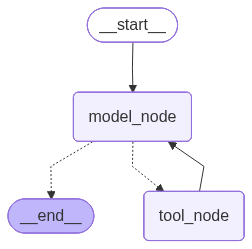

In [42]:
app

{'messages': [HumanMessage(content='What is the weather of Delhi', additional_kwargs={}, response_metadata={}, id='81a6b1b2-a366-4b65-8cd7-be0c4e596d60'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'weather_tool', 'arguments': '{"query": "Delhi"}'}}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': [], 'grounding_metadata': {}, 'model_provider': 'google_genai'}, id='lc_run--f39c40f9-c522-4e1a-b746-117debb5e3ef-0', tool_calls=[{'name': 'weather_tool', 'args': {'query': 'Delhi'}, 'id': 'b618e168-1bdc-47d4-ad5b-5919e64afae5', 'type': 'tool_call'}], usage_metadata={'input_tokens': 47, 'output_tokens': 72, 'total_tokens': 119, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 57}}),
  ToolMessage(content='The weather is 70 degrees and sunny.', id='7faafc5a-4d41-4a64-945f-45f9a9564e10', tool_call_id='b618e168-1bdc-47d4-ad5b-5919e

# Pattern 2: Reflection (Build)

## How to build it:

### State
- Add fields to your state to hold the critique and grade

### Nodes
- Create two distinct nodes:
    - `generate_node`
    - `reflect_node`

### Conditional Edge
- Create a function that routes based on the grade field

In [62]:
import random
from typing import TypedDict, Annotated
from langgraph.graph import StateGraph, END
from langgraph.graph.message import add_messages
from langchain_core.messages import SystemMessage

# 1. State
class ReflectState(TypedDict):
    messages: Annotated[list, add_messages]
    grade: str # Our new field

# 2. Nodes
def generate_node(state: ReflectState):
    print("---GENERATE NODE---")
    # In a real app, you'd call an LLM
    # If a critique exists, you'd add it to the prompt

    if "grade" in state:
      sysMsg = SystemMessage(content = f"""You are an expert article writer : Write a article in 30 words given the topic and take the critique as input
          Critique : {state["grade"]}
      """)
    else:
      sysMsg = SystemMessage(content = "You are an expert article writer : Write an article in 30 words given the topic")

    print(sysMsg)
    response_text = llm.invoke([sysMsg] + state["messages"]).content
    return {"messages": [("ai", response_text)]}

def reflect_node(state: ReflectState):
    print("---REFLECT NODE---")
    # In a real app, you'd call an LLM as a "critic"
    # Here, we'll just randomly "grade" the last AI message
    grade = random.choice(["good", "bad"])
    print(f"My grade is: {grade}")
    return {"grade": grade}

# 3. Conditional Logic
def reflection_router(state: ReflectState):
    print("---CHECKING GRADE---")
    if state['grade'] == "good":
        return END
    else:
        return "generate_node" # Loop back to the 'generate' node

# --- Graph Setup ---
workflow = StateGraph(ReflectState)
workflow.add_node("generate_node", generate_node)
workflow.add_node("reflect_node", reflect_node)

workflow.set_entry_point("generate_node")

# After generating, always reflect
workflow.add_edge("generate_node", "reflect_node")

# After reflecting, use our conditional logic
workflow.add_conditional_edges(
    "reflect_node",
    reflection_router,
    {
        END: END,
        "generate_node": "generate_node"
    }
)

app = workflow.compile()

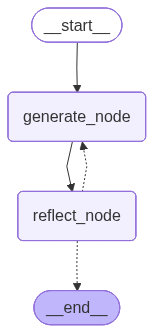

In [63]:
app

In [64]:
app.invoke({"messages": [("human", "Politics")]})

---GENERATE NODE---
content='You are an expert article writer : Write an article in 30 words given the topic' additional_kwargs={} response_metadata={}
---REFLECT NODE---
My grade is: bad
---CHECKING GRADE---
---GENERATE NODE---
content='You are an expert article writer : Write a article in 30 words given the topic and take the critique as input \n          Critique : bad\n      ' additional_kwargs={} response_metadata={}
---REFLECT NODE---
My grade is: bad
---CHECKING GRADE---
---GENERATE NODE---
content='You are an expert article writer : Write a article in 30 words given the topic and take the critique as input \n          Critique : bad\n      ' additional_kwargs={} response_metadata={}
---REFLECT NODE---
My grade is: good
---CHECKING GRADE---


{'messages': [HumanMessage(content='Politics', additional_kwargs={}, response_metadata={}, id='a48782ad-de69-4003-94d0-872db2f8decb'),
  AIMessage(content="Politics shapes our world, from local decisions to global affairs. It's the art of governance, power, and influencing society's direction through debate and compromise.", additional_kwargs={}, response_metadata={}, id='9e7d92eb-8ad0-498a-84ee-3f0c95c8788e'),
  AIMessage(content='', additional_kwargs={}, response_metadata={}, id='dbb092bc-9bf5-43e7-9fba-2d2350653911'),
  AIMessage(content="**Politics: The Engine of Society**\n\nPolitics drives societal change, shaping laws and policies. It's the dynamic process of decision-making, negotiation, and power distribution that impacts every aspect of our lives.", additional_kwargs={}, response_metadata={}, id='560fdba1-6d6e-4b75-a31c-a32c8b50a5c6')],
 'grade': 'good'}

# Pattern 3: Planning (Build)

## How to build it:

### State
- Track the plan, results of past steps, and original goal
- Use TypedDict with fields for:
    - original_question
    - plan (list of steps)
    - past_steps (executed steps and results)
    - response (final output)

### Nodes
Three core components:
- **planner_node**: Creates initial step-by-step plan
- **execute_node**: Runs current step and stores result
- **replanner_node**: Evaluates progress and decides next action

### Conditional Edge  
- After execution, route to replanner
- Replanner decides to:
    - Continue executing
    - Create new plan
    - Finish with response

In [9]:
from typing import List, Tuple
from pydantic import BaseModel
from typing import TypedDict

class Plan(BaseModel):
  plan : List[str]

In [10]:
llm_with_structured_output = llm.with_structured_output(Plan)

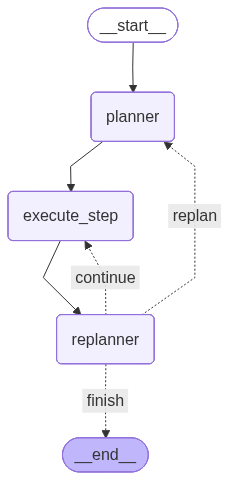

In [24]:
from typing import List, Tuple
from langgraph.graph import StateGraph,END
from langchain_core.messages import SystemMessage, HumanMessage

# 1. State
class PlanningState(TypedDict):
    original_question: str
    plan: List[str]
    past_steps: List[Tuple[str, str]] # (step, result)
    response: str # Final response

# 2. Nodes
def planner_node(state: PlanningState):
    # Call LLM to create a plan based on 'original_question'
    sysMsg = SystemMessage(content = "You are expert planner. Create a plan to answer the question")
    humanMsg = HumanMessage(content = f"{state["original_question"]}")
    new_plan = llm_with_structured_output.invoke([sysMsg] + [humanMsg]).plan
    print(new_plan)
    return {"plan": new_plan}

def execute_node(state: PlanningState):
    # Get next step from state['plan']
    next_step = state['plan'][0]
    remaining_plan = state['plan'][1:]

    print(f"Here is the next step : {next_step}")
    print(f"Here is the remaining plan : {remaining_plan}")
    # ... execute the step (often a tool call) ...
    result = f"Executed {next_step}"

    if "past_steps" in state:
      new_past_steps = state['past_steps'] + [(next_step, result)]
    else:
      new_past_steps = [(next_step, result)]
    return {"plan": remaining_plan, "past_steps": new_past_steps}

def replanner_node(state: PlanningState):
    needs_new_plan = input("Would you like to replan?")
    ## Plan is complete
    if len(state["plan"]) == 0:
      return {"response" : state["past_steps"][-1][1], "next_action" : "finish"}
    elif needs_new_plan == "Yes":
      return {"next_action" : "replan"}
    else:
      return {"next_action": "continue"}

# --- Graph Setup ---
workflow = StateGraph(PlanningState)
workflow.add_node("planner", planner_node)
workflow.add_node("execute_step", execute_node)
workflow.add_node("replanner", replanner_node)

workflow.set_entry_point("planner")
workflow.add_edge("planner", "execute_step")
workflow.add_edge("execute_step", "replanner")

# 3. Conditional Edge
workflow.add_conditional_edges(
    "replanner",
    lambda x: x["next_action"], # Get decision from state
    {
        "continue": "execute_step", # Loop to execute next step
        "replan": "planner",        # Go back to replan
        "finish": END
    }
)

app = workflow.compile()

app

In [26]:
app.invoke({"original_question":"How would I solve for finding longest common subsequence"})

['Explain the concept of the longest common subsequence (LCS) problem.', 'Describe the dynamic programming approach to solve the LCS problem.', 'Provide a step-by-step algorithm for finding the LCS using dynamic programming.', 'Illustrate the algorithm with a simple example.', 'Discuss the time and space complexity of the dynamic programming solution.', 'Mention any alternative approaches or optimizations, if applicable.']
Here is the next step : Explain the concept of the longest common subsequence (LCS) problem.
Here is the remaining plan : ['Describe the dynamic programming approach to solve the LCS problem.', 'Provide a step-by-step algorithm for finding the LCS using dynamic programming.', 'Illustrate the algorithm with a simple example.', 'Discuss the time and space complexity of the dynamic programming solution.', 'Mention any alternative approaches or optimizations, if applicable.']
Would you like to replan?no
Here is the next step : Describe the dynamic programming approach to

{'original_question': 'How would I solve for finding longest common subsequence',
 'plan': [],
 'past_steps': [('Explain the concept of the longest common subsequence (LCS) problem.',
   'Executed Explain the concept of the longest common subsequence (LCS) problem.'),
  ('Describe the dynamic programming approach to solve the LCS problem.',
   'Executed Describe the dynamic programming approach to solve the LCS problem.'),
  ('Provide a step-by-step algorithm for finding the LCS using dynamic programming.',
   'Executed Provide a step-by-step algorithm for finding the LCS using dynamic programming.'),
  ('Illustrate the algorithm with a simple example.',
   'Executed Illustrate the algorithm with a simple example.'),
  ('Discuss the time and space complexity of the dynamic programming solution.',
   'Executed Discuss the time and space complexity of the dynamic programming solution.'),
  ('Mention any alternative approaches or optimizations, if applicable.',
   'Executed Mention any al

# Pattern 4: Multi-Agent (Build)

## How to build it:

This pattern uses a central "router" to pass control between agents.

You can build:
- Separate graphs for each agent and "nest" them, or
- One graph where each "node" represents a different agent

## Simple Example: Two-Agent Debate

### State
- messages (the full conversation)
- turn (which agent speaks next)

### Nodes
- agent_a_node
- agent_b_node

### Conditional Edge
- A "router" function that:
    - checks the turn field
    - checks for a "FINISH" keyword



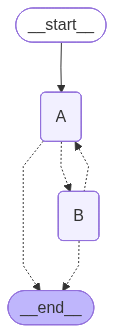

In [38]:
from typing import Annotated
from langgraph.graph import add_messages

# 1. State
class DebateState(TypedDict):
    messages: Annotated[list, add_messages]
    # 'turn' will be 'A' or 'B'
    turn: str

# 3. Conditional Logic
def debate_router(state: DebateState):
    # Simple stop condition
    if len(state['messages']) > 10 or "FINISH" in state['messages'][-1].content:
        return END
    # Route to the agent whose turn it is
    return state['turn']

# 2. Nodes
def agent_a_node(state: DebateState):
    # ... call LLM for agent A ...
    new_message = llm.invoke(state["messages"])
    print(f"AGENT A: {new_message.content}")
    # Return the message and set the turn to 'B'
    return {"messages": [new_message], "turn": "B"}

def agent_b_node(state: DebateState):
    # ... call LLM for agent B ...
    new_message = llm.invoke(state["messages"])
    print(f"AGENT B: {new_message.content}")
    # Return the message and set the turn to 'A'
    return {"messages": [new_message], "turn": "A"}

# --- Graph Setup ---
workflow = StateGraph(DebateState)
workflow.add_node("A", agent_a_node)
workflow.add_node("B", agent_b_node)

# The router is the "Coordinator"
# We start the debate by routing to Agent A
workflow.set_entry_point("A")

# After Agent A speaks, route
workflow.add_conditional_edges(
    "A",
    debate_router,
    {
        "B": "B",
        END: END
    }
)

# After Agent B speaks, route
workflow.add_conditional_edges(
    "B",
    debate_router,
    {
        "A": "A",
        END: END
    }
)

app = workflow.compile()

app


In [39]:
for state in app.stream({"messages": [("user", "Start debating!")] , "turn": "A"}):
    if "messages" in state:
        last_message = state["messages"][-1]
        if last_message.type == "ai":
            print(f"AI: {last_message.content}")
        elif last_message.type == "human":
            print(f"Human: {last_message.content}")
    if "turn" in state:
        print(f"Turn: {state['turn']}")
    print("---")

AGENT A: Alright, let's get this debate rolling! To make it productive, we need a topic.

**What subject are we debating today?**

Give me a proposition, a statement, or a question that sparks disagreement. The more specific, the better!

For example, we could debate:

*   **"The rise of AI will ultimately lead to more job losses than job creation."**
*   **"Social media has a net negative impact on mental health."**
*   **"Universal Basic Income is a viable solution to poverty."**
*   **"The death penalty is a just punishment."**
*   **"Space exploration is a worthwhile investment of public funds."**

**Your turn! What's our battleground?**
---
AGENT B: 
---
AGENT A: Excellent! I'm ready.

Let's debate this proposition:

**"The benefits of remote work outweigh the drawbacks for both employees and employers."**

I'll take the affirmative side, arguing that the benefits are indeed greater.

**What's your stance? Are you arguing for the negative, or do you have a different proposition in